# INFO-6147-(01)-26W Deep Learning with TensorFlow/Keras

## Project: Flavor Bridge

**Student Name:** Yun-Jiung Wang

**Student Number:** 1256222

**Date:** March 30th, 2026

**GitHub:** [Tensorflow & Keras](https://github.com/virwang/Tensorflow-Keras_Fanshawe.git)

**Description:**

This project aims to allow users to upload photos of food and describe what the food tastes like. It will be helpful when traveling or when people want to try international food but don't have someone to explain it.
Here comes this AI project, to assist people on observing new foods.

## Setup Environment

In [ ]:
# !pip install datasets gradio streamlit groq pyngrok

# # Download Cloudflare tunnel tool (for Streamlit tunneling in Colab)
# !wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
# !dpkg -i cloudflared-linux-amd64.deb

## Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import zipfile
import io
import gc

# ── TensorFlow / Keras ──────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications, optimizers, callbacks,regularizers


# sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import seaborn as sns
from tqdm import tqdm

from google.colab import userdata, runtime, drive

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")

# clear sessions
tf.keras.backend.clear_session()

TensorFlow version: 2.19.0
Keras version:      3.13.2


## Define Path Parameters

In [3]:
SOURCE_DRIVE_ZIP  = "/content/drive/MyDrive/food-101.tar.gz"
TARGET_LOCAL_ROOT = "/content/food101_local"

# Best-model save path  (TF uses .keras or SavedModel format instead of .pth)
MODEL_SAVE_PATH = "/content/drive/MyDrive/food_best.keras"

## Define GPU usage

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

## Connect to Google Drive

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


## Data Preparation & Curation

### Define Food Types for Subset

In [6]:
select_food_list = sorted([
    # --- Asia ---
    'bibimbap', 'gyoza', 'sashimi', 'pad_thai', 'pho',
    'miso_soup', 'edamame', 'spring_rolls', 'sushi', 'dumplings',
    'hummus', 'falafel', 'baklava', 'chicken_curry', 'fried_rice',

    # --- Latino ---
    'tacos', 'guacamole', 'ceviche', 'nachos',

    # --- Classic ---
    'pizza', 'hamburger', 'hot_dog', 'steak', 'french_fries',
    'grilled_salmon', 'spaghetti_bolognese', 'lasagna', 'club_sandwich',

    # --- Hot in Social Media ---
    'tiramisu', 'cheesecake', 'macarons', 'donuts', 'waffles',
    'pancakes', 'ice_cream', 'apple_pie', 'strawberry_shortcake',

    # --- Seafood ---
    'mussels', 'oysters',

    # --- Europe ---
    'escargots'
])

# Mapping dictionaries
class_to_idx = {cls_name: i for i, cls_name in enumerate(select_food_list)}
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}
label_to_name = {i: name for i, name in enumerate(select_food_list)}

select = [
    {"Class Index": class_idx, "Class Name": class_name}
    for class_name, class_idx in class_to_idx.items()
]
df_select = pd.DataFrame(select)
display(df_select.head())
print(len(select_food_list))

,Class Index,Class Name
0,0,apple_pie
1,1,baklava
2,2,bibimbap
3,3,ceviche
4,4,cheesecake


40


#### Clean Up Old Data & Extract from Google Drive

In [7]:
# 1. Clean up old data to avoid 'Ghost Folders'
!rm -rf /content/food101_local
os.makedirs(TARGET_LOCAL_ROOT, exist_ok=True)

In [8]:
# 2. Extract only the 40 selected categories from the archive
extract_targets = [f"food-101/images/{food}" for food in select_food_list]
extract_targets.append("food-101/meta")
targets_str = " ".join(extract_targets)

print(f"🚀 Extracting ONLY {len(select_food_list)} categories...")
!tar -xzf "{SOURCE_DRIVE_ZIP}" -C "{TARGET_LOCAL_ROOT}" {targets_str}

# 3. Validate
images_path = os.path.join(TARGET_LOCAL_ROOT, "food-101/images")
actual_folders = os.listdir(images_path)
print(f"✅ Extraction successful! Total folders: {len(actual_folders)}")

if len(actual_folders) != 40:
    print(f"⚠️ Warning: Expected 40 but found {len(actual_folders)}")

🚀 Extracting ONLY 40 categories...
✅ Extraction successful! Total folders: 40


## Data Pipeline Infrastructure

### Hyperparameters

In [9]:
EPOCHS       = 5
BATCH_SIZE   = 64
LEARNING_RATE = 0.0001
PATIENCE     = 10   # early stopping
IMG_SIZE     = 224  # ResNet50 input size
NUM_CLASSES  = len(select_food_list)  # 40

### Load Dataset, Split & Build tf.data Pipelines

**TensorFlow approach:** Collect file paths + labels → stratified split → `tf.data.Dataset` with `map()` for transforms

In [10]:
# ── 1. Collect all image paths and their integer labels ───────────────────────
all_paths, all_labels = [], []

# ImageFolder orders classes alphabetically – we match that here
extracted_classes = sorted(os.listdir(images_path))
extracted_class_to_idx = {cls: i for i, cls in enumerate(extracted_classes)}

for class_name in extracted_classes:
    class_dir = os.path.join(images_path, class_name)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append(os.path.join(class_dir, fname))
            all_labels.append(extracted_class_to_idx[class_name])

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)
print(f"Total images collected: {len(all_paths)}")
print(f"Total classes detected: {len(extracted_classes)}")
print(f"Sample mapping (first 3): {dict(list(extracted_class_to_idx.items())[:3])}")

# ── 2. Stratified split: 80% Train | 10% Val | 10% Test ──────────────────────
indices = np.arange(len(all_paths))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, stratify=all_labels, random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=all_labels[temp_idx], random_state=42
)

print(f"\n Final Data Preprocessing Complete:")
print(f"Total Classes: {len(extracted_classes)}")
print(f"Training size: {len(train_idx)} (Augmented)")
print(f"Validation size: {len(val_idx)} (Clean)")
print(f"Test size: {len(test_idx)} (Clean)")

Total images collected: 40000
Total classes detected: 40
Sample mapping (first 3): {'apple_pie': 0, 'baklava': 1, 'bibimbap': 2}

 Final Data Preprocessing Complete:
Total Classes: 40
Training size: 32000 (Augmented)
Validation size: 4000 (Clean)
Test size: 4000 (Clean)


In [11]:
# ── 3. Image loading helper ───────────────────────────────────────────────────
def load_image(path, label):
    """Read a JPEG/PNG from disk and decode it."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)
    return img, label


# ── 4. Augmentation transforms ────────────────────────────────────────────────
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

def normalize(img):
    """ImageNet normalization (same values as PyTorch version)."""
    img = img / 255.0
    return (img - IMAGENET_MEAN) / IMAGENET_STD

def train_augment(img, label):
    """Training augmentation pipeline optimized for speed."""

    # [ADJUSTMENT] RandomResizedCrop alternative
    # Reason: Standard TF functions are significantly faster than py_function.
    img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE + 32, IMG_SIZE + 32)
    img = tf.image.random_crop(img, size=[IMG_SIZE, IMG_SIZE, 3])

    # [ADJUSTMENT] Replaced slow rotation with native TF operations
    # Reason: tf.py_function breaks the execution graph and forces single-thread execution.
    # Native operations (flip, brightness, contrast) run entirely on the optimized backend.
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)

    img = normalize(img)
    return img, label

def eval_transform(img, label):
    """Validation / test transform: Resize(256) → CenterCrop(224) → Normalize."""
    img = tf.image.resize(img, [256, 256])
    # CenterCrop to 224
    offset = (256 - IMG_SIZE) // 2
    img = img[offset:offset + IMG_SIZE, offset:offset + IMG_SIZE, :]
    img = normalize(img)
    return img, label


# ── 5. Build tf.data.Dataset objects ─────────────────────────────────────────

AUTOTUNE = tf.data.AUTOTUNE
def build_dataset(paths, labels, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    # [ADJUSTMENT] First Map: Basic Loading
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    # [ADJUSTMENT] Strategic Caching
    # Reason: Caching here stores decoded images in RAM.
    # Subsequent epochs skip disk I/O and decoding entirely.
    ds = ds.cache()

    if augment:
        # [ADJUSTMENT] Second Map: Parallel Augmentation
        # Reason: Since images are already in RAM (cached), CPU only focuses on math transforms.
        ds = ds.map(train_augment, num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(buffer_size=1000)
    else:
        ds = ds.map(eval_transform, num_parallel_calls=AUTOTUNE)

    # [ADJUSTMENT] Batch and Prefetch
    # Reason: Prefetch allows the CPU to prepare the next batch while the GPU is training.
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# Clear any previous graph state to free up RAM
tf.keras.backend.clear_session()

# Re-initialize datasets
train_ds = build_dataset(all_paths[train_idx], all_labels[train_idx], augment=True)
val_ds   = build_dataset(all_paths[val_idx],   all_labels[val_idx],   augment=False)
test_ds  = build_dataset(all_paths[test_idx],  all_labels[test_idx],  augment=False)

print("✅ High-performance pipelines ready. Step time should drop significantly.")

✅ High-performance pipelines ready. Step time should drop significantly.


#### Validate Selected Food Labels

In [12]:
sorted_original_list = sorted(select_food_list)
is_match = (extracted_classes == sorted_original_list)

print("--- Synchronization Check ---")
print(f"Detected Classes:  {len(extracted_classes)}")
print(f"Your Original List: {len(sorted_original_list)}")
print(f"Perfect Match? {is_match}")

if not is_match:
    missing = set(sorted_original_list) - set(extracted_classes)
    extra   = set(extracted_classes) - set(sorted_original_list)
    if missing: print(f"❌ Missing on disk: {missing}")
    if extra:   print(f"⚠️  Extra on disk: {extra}")
else:
    print("✅ Success: The labels 0-39 match your list perfectly.")

--- Synchronization Check ---
Detected Classes:  40
Your Original List: 40
Perfect Match? True
✅ Success: The labels 0-39 match your list perfectly.


## Collect Final Predictions on the Test Set

In [13]:
def get_final_predictions(model,dataset):
  # predict the whole dataset
  # verbose=1 show progress bar
  y_pred_probs = model.predict(dataset, verbose=1)
  y_pred = np.argmax(y_pred_probs, axis=1)

  # get y_true
  # to make sure the order of label matches the y_true labels, loop dataset to get labels
  y_true = []
  for _, labels in dataset:
    y_true.extend(labels.numpy())
    y_true = np.array(y_true)

  return y_true, y_pred

## Define the FoodClassifier Training Wrapper

In [14]:
# 1. Save the best model (by val_loss)
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

# 2. Reduce LR on plateau
reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    mode='min',
    verbose=1
)

# 3. Early stopping
early_stop_cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    mode='min',
    restore_best_weights=True,   # auto-loads best weights at end of training
    verbose=1
)

print("✅ Callbacks configured.")

✅ Callbacks configured.


## Build the Model

**TensorFlow/Keras:** `tf.keras.applications.ResNet50(weights='imagenet')` + custom Dense head

### Model Architecture Definition

In [15]:
def build_food_model(num_classes: int) -> keras.Model:
    """
    Constructs a ResNet50-based model with a funnel-structured classification head.
    The funnel design (512 -> 256) helps consolidate food features more effectively.
    """

    # Load pre-trained ResNet50 as the feature extractor
    base_model = applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # PHASE 1: Freeze backbone to protect pre-trained ImageNet weights
    base_model.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Using training=False for the backbone ensures BatchNormalization stays in inference mode
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Classification Head - Layer 1: 512 neurons with L2 regularization
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    # Classification Head - Layer 2: 256 neurons (Funneling down)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    # Output layer - using float32 for numerical stability in softmax calculation
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    return keras.Model(inputs, outputs, name='FlavorBridge_Full_Model')

# Initialize the model
model = build_food_model(NUM_CLASSES)
model.summary(line_length=80)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "FlavorBridge_Full_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ resnet50 (Functional)             │ (None, 7, 7, 2048)       │    23,587,712 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 2048)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 512)              │     1,049,088 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 512)              │         2,048 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation (Activation)           │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 256)              │       131,328 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_1             │ (None, 256)              │         1,024 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_1 (Activation)         │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 40)               │        10,280 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 24,781,480 (94.53 MB)

 Trainable params: 1,192,232 (4.55 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

### Feature Extraction (Training the Head)

In [16]:
print("\n[INFO] Starting Phase 1: Training the classification head...")

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4), # Relatively higher LR for the new head
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Training only the top layers
history_phase1 = model.fit(
    train_ds,
    epochs=10, # Initial warm-up training
    validation_data=val_ds,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb]
)


[INFO] Starting Phase 1: Training the classification head...
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0547 - loss: 4.0386
Epoch 1: val_loss improved from None to 3.41426, saving model to /content/drive/MyDrive/food_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/food_best.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 98ms/step - accuracy: 0.0779 - loss: 3.8446 - val_accuracy: 0.1475 - val_loss: 3.4143 - learning_rate: 1.0000e-04
Epoch 2/10
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1216 - loss: 3.5559
Epoch 2: val_loss improved from 3.41426 to 3.28358, saving model to /content/drive/MyDrive/food_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/food_best.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.1260 - loss: 3.5185 - val_accuracy: 0.1797 - val_loss: 3.2836 - learning_rate: 1.0000e-04
Epoch 3/10
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1402 - loss: 3.4190
Epoch 3: val_loss improv

## Read the traning result of Phase1

In [17]:
model = tf.keras.models.load_model('/content/drive/MyDrive/food_best.keras')
print("Successfully loaded the pre-trained weights.")

Successfully loaded the pre-trained weights.


### Fine Tuning: Unfreezing the Backbone

In [18]:
print("\n[INFO] Starting Phase 2: Unfreezing backbone for fine-tuning...")

# Unfreeze the base model (ResNet50)
model.layers[1].trainable = True

# CRITICAL: Re-compile with a much lower learning rate for fine-tuning
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5), # 10x lower to avoid ruining weights
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training the entire network
history_fine = model.fit(
    train_ds,
    epochs=15, # Extra epochs to learn specific food textures/shapes
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)


[INFO] Starting Phase 2: Unfreezing backbone for fine-tuning...
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.2100 - loss: 3.1087
Epoch 1: val_loss did not improve from 2.96798
500/500 ━━━━━━━━━━━━━━━━━━━━ 110s 101ms/step - accuracy: 0.2800 - loss: 2.8121 - val_accuracy: 0.2383 - val_loss: 3.0265
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4166 - loss: 2.3248
Epoch 2: val_loss improved from 2.96798 to 2.01058, saving model to /content/drive/MyDrive/food_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/food_best.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 88ms/step - accuracy: 0.4397 - loss: 2.2487 - val_accuracy: 0.5330 - val_loss: 2.0106
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5079 - loss: 2.0178
Epoch 3: val_loss improved from 2.01058 to 1.78451, saving model to /content/drive/MyDrive/food_best.keras

Epoch 3: finished saving model to /content/drive/MyDrive/food_best.keras
500/500 ━━━━━━━━━━━━━━━━━

### Model Serialization & Persistence (Saving & Cleanup)

Save the final optimized model to Google Drive

In [19]:
FINAL_MODEL_PATH = '/content/drive/MyDrive/flavor_bridge_final.keras'
model.save(FINAL_MODEL_PATH)
print(f"\n✅ SUCCESS: Final model saved to {FINAL_MODEL_PATH}")

# Explicit memory management to prevent OOM
gc.collect()
tf.keras.backend.clear_session()

full_history = {
    'train_loss': history_phase1.history['loss'] + history_fine.history['loss'],
    'train_acc':  [v * 100 for v in (history_phase1.history['accuracy'] + history_fine.history['accuracy'])],
    'test_loss':  history_phase1.history['val_loss'] + history_fine.history['val_loss'],
    'test_acc':   [v * 100 for v in (history_phase1.history['val_accuracy'] + history_fine.history['val_accuracy'])],
    'lr':         history_phase1.history.get('lr', []) + history_fine.history.get('lr', [])
}


✅ SUCCESS: Final model saved to /content/drive/MyDrive/flavor_bridge_final.keras


### Get full history

In [25]:
full_history = {
    'train_loss': history_phase1.history['loss'] + history_fine.history['loss'],
    'train_acc':  [v * 100 for v in (history_phase1.history['accuracy'] + history_fine.history['accuracy'])],
    'test_loss':  history_phase1.history['val_loss'] + history_fine.history['val_loss'],
    'test_acc':   [v * 100 for v in (history_phase1.history['val_accuracy'] + history_fine.history['val_accuracy'])],
    'lr':         history_phase1.history.get('lr', []) + history_fine.history.get('lr', [])
}

## Model Evaluation


In [26]:
class ModelEvaluator:
    """
    Evaluate model performance: metrics, confusion matrix,
    detailed report, and visual inference.
    """

    def __init__(self, history, y_true, y_pred, class_names, test_ds=None):
        self.history     = history
        self.y_true      = np.array(y_true)
        self.y_pred      = np.array(y_pred)
        self.class_names = class_names
        self.test_ds     = test_ds

    # ── Plot helpers ───────────────────────────────────────────────────────────

    def plot_accuracy(self):
        """Show Accuracy curve."""
        plt.figure(figsize=(10, 6))
        epochs = range(1, len(self.history['train_loss']) + 1)
        plt.plot(epochs, self.history['train_acc'], 'g-o', label='Train Acc', markersize=4)
        plt.plot(epochs, self.history['test_acc'],  'm-s', label='Val Acc',   markersize=4)
        plt.title('Accuracy Trend: Training vs Validation', fontsize=15, pad=15)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Accuracy (%)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

    def plot_loss(self):
        """Show Loss convergence."""
        plt.figure(figsize=(10, 6))
        epochs = range(1, len(self.history['train_loss']) + 1)
        plt.plot(epochs, self.history['train_loss'], 'b-o', label='Train Loss', markersize=4)
        plt.plot(epochs, self.history['test_loss'],  'r-s', label='Val Loss',   markersize=4)
        plt.title('Loss Convergence: Training vs Validation', fontsize=15, pad=15)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Loss Value', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

    def plot_learning_rate(self):
        """Show Learning Rate schedule."""
        if self.history.get('lr') and len(self.history['lr']) > 0:
            plt.figure(figsize=(10, 6))
            epochs = range(1, len(self.history['lr']) + 1)
            plt.plot(epochs, self.history['lr'], 'k-x', label='LR')
            plt.yscale('log')
            plt.title('Learning Rate Schedule', fontsize=15, pad=15)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('LR (Log Scale)', fontsize=12)
            plt.grid(True, which='both', ls='-', alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No Learning Rate data recorded in history.")

    def plot_f1_score(self):
        """Show F1-Score trend (if available)."""
        if self.history.get('test_f1') and len(self.history['test_f1']) > 0:
            plt.figure(figsize=(10, 6))
            epochs = range(1, len(self.history['test_f1']) + 1)
            plt.plot(epochs, self.history['test_f1'], 'c-^', label='Test F1 (Macro)')
            plt.title('Model Balance: F1-Score Trend', fontsize=15, pad=15)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('F1 Score', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No per-epoch F1 data. See print_detailed_analysis() for the final F1.")

    def plot_confusion_matrix(self, figsize=(18, 14)):
        """Filtered Confusion Matrix: Top 5 & Worst 5 categories by F1."""
        report = classification_report(
            self.y_true, self.y_pred,
            target_names=self.class_names,
            output_dict=True, zero_division=0
        )
        class_stats  = {k: v['f1-score'] for k, v in report.items() if k in self.class_names}
        sorted_cls   = sorted(class_stats.items(), key=lambda x: x[1], reverse=True)
        top_5        = [x[0] for x in sorted_cls[:5]]
        worst_5      = [x[0] for x in sorted_cls[-5:]]
        selected_cls = top_5 + worst_5
        indices      = [list(self.class_names).index(c) for c in selected_cls]

        cm          = confusion_matrix(self.y_true, self.y_pred)
        filtered_cm = cm[np.ix_(indices, indices)]

        plt.figure(figsize=figsize)
        sns.heatmap(filtered_cm, annot=True, fmt='d', cmap='YlGnBu',
                    xticklabels=selected_cls, yticklabels=selected_cls,
                    annot_kws={'size': 10})
        plt.title('Confusion Matrix: Top 5 & Worst 5 Categories', fontsize=16)
        plt.ylabel('Actual Food Type', fontsize=12)
        plt.xlabel('Predicted Food Type', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.axhline(y=5, color='red', linestyle='--', linewidth=2, alpha=0.5)
        plt.axvline(x=5, color='red', linestyle='--', linewidth=2, alpha=0.5)
        plt.text(0.5, 4.8,  'Top 5',   color='green', fontweight='bold')
        plt.text(5.5, 9.8,  'Worst 5', color='red',   fontweight='bold')
        plt.tight_layout()
        plt.show()

    def print_detailed_analysis(self):
        """Classification report + worst 5 classes."""
        print("\n" + "=" * 60)
        print("DETAILED CLASSIFICATION PERFORMANCE")
        print("=" * 60)
        all_labels = list(range(len(self.class_names)))
        report = classification_report(
            self.y_true, self.y_pred,
            target_names=self.class_names,
            labels=all_labels,
            output_dict=True, zero_division=0
        )
        class_stats = {k: v for k, v in report.items() if k in self.class_names}
        worst_5     = sorted(class_stats.items(), key=lambda x: x[1]['f1-score'])[:5]

        print(f"{'Food Class':<20} | {'F1-Score':<10} | {'Precision':<10} | {'Recall':<10}")
        print("-" * 60)
        for name, stats in worst_5:
            print(f"{name:<20} | {stats['f1-score']:.4f} | {stats['precision']:.4f} | {stats['recall']:.4f}")

        final_f1 = f1_score(self.y_true, self.y_pred, average='macro')
        print(f"\nFinal Macro F1-Score: {final_f1:.4f}")

    def visualize_predictions(self, num_images=15):
      if self.test_ds is None:
          print("Error: test_ds must be provided.")
          return

      MEAN = np.array([0.485, 0.456, 0.406])
      STD  = np.array([0.229, 0.224, 0.225])

      # 1 batch
      images, labels = next(iter(self.test_ds.take(1)))

      plt.figure(figsize=(20, 12))
      for i in range(num_images):
          ax = plt.subplot(3, 5, i + 1)
          img = np.clip(STD * images[i].numpy() + MEAN, 0, 1)

          true_name = self.class_names[labels[i].numpy()]
          pred_name = self.class_names[self.y_pred[i]] # read predict result

          color = 'green' if labels[i].numpy() == self.y_pred[i] else 'red'
          plt.imshow(img)
          ax.set_title(f"True: {true_name}\nPred: {pred_name}", color=color, fontweight='bold')
          ax.axis('off')
      plt.tight_layout()
      plt.show()

## Run Evaluation

In [22]:
print("\n[INFO] Generating predictions for evaluation...")

y_pred_probs = model.predict(test_ds, verbose=1)
final_y_pred = np.argmax(y_pred_probs, axis=1)

final_y_true = []
for _, labels in test_ds:
    final_y_true.extend(labels.numpy())
final_y_true = np.array(final_y_true)

# remove cache
del y_pred_probs
gc.collect()
tf.keras.backend.clear_session()

63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step


In [27]:
evaluation = ModelEvaluator(
    history=full_history,
    y_true=final_y_true,
    y_pred=final_y_pred,
    class_names=extracted_classes,
    test_ds=test_ds
)

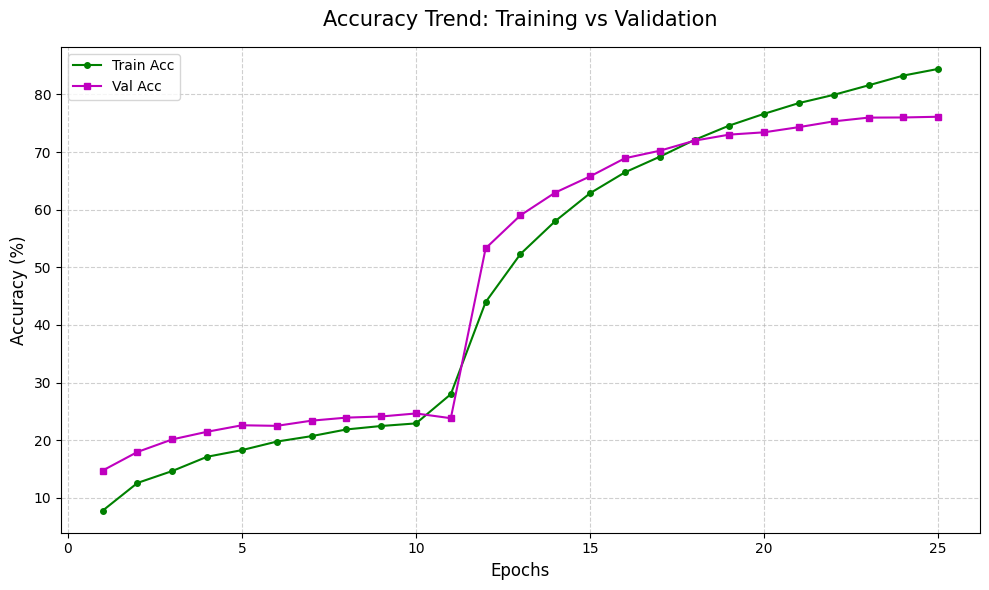

In [28]:
evaluation.plot_accuracy()

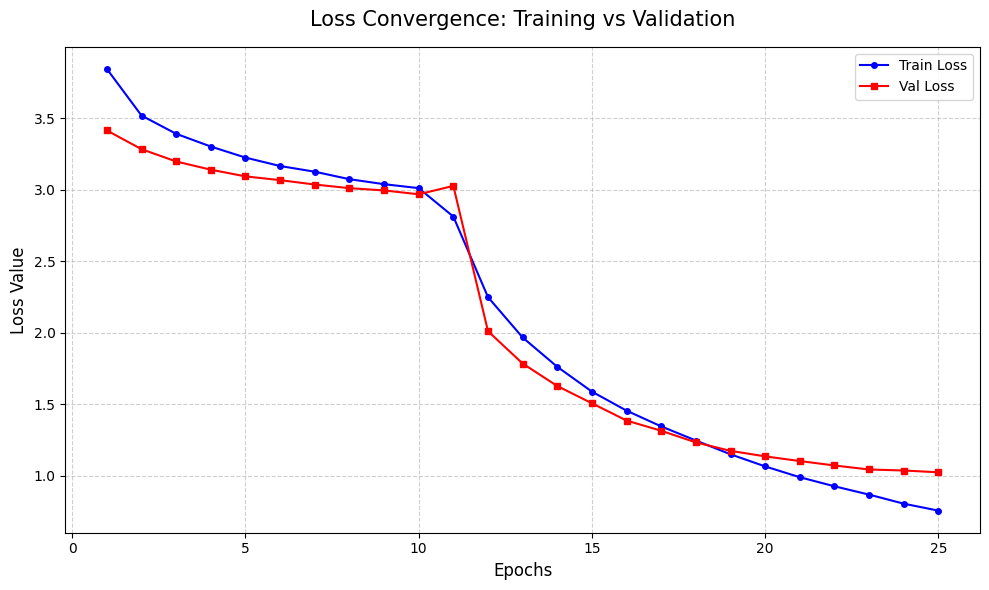

In [29]:
evaluation.plot_loss()

In [30]:
evaluation.plot_learning_rate()

No Learning Rate data recorded in history.


In [31]:
evaluation.plot_f1_score()

No per-epoch F1 data. See print_detailed_analysis() for the final F1.


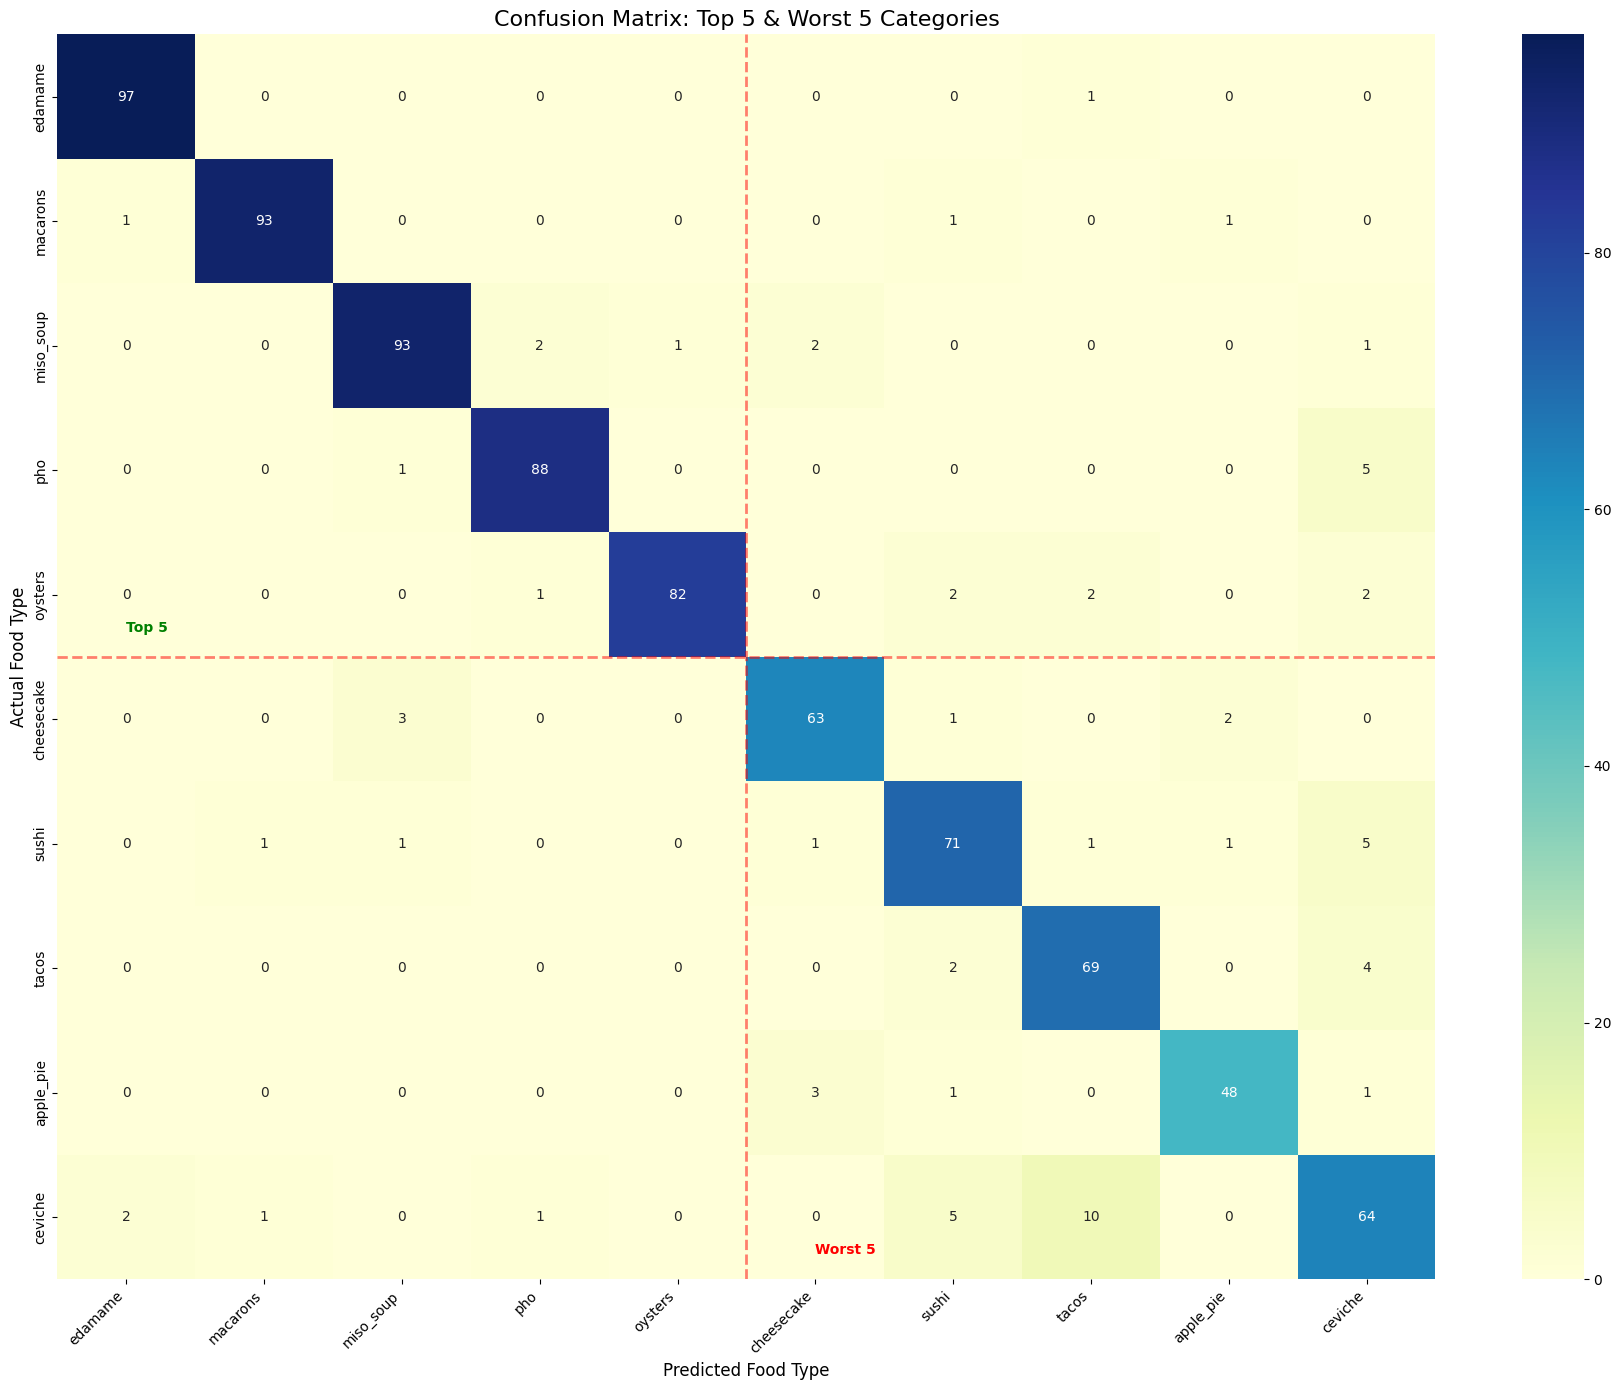

In [32]:
evaluation.plot_confusion_matrix()

In [33]:
evaluation.print_detailed_analysis()


DETAILED CLASSIFICATION PERFORMANCE
Food Class           | F1-Score   | Precision  | Recall    
------------------------------------------------------------
ceviche              | 0.5311 | 0.4539 | 0.6400
apple_pie            | 0.5393 | 0.6154 | 0.4800
tacos                | 0.6106 | 0.5476 | 0.6900
sushi                | 0.6228 | 0.5547 | 0.7100
cheesecake           | 0.6396 | 0.6495 | 0.6300

Final Macro F1-Score: 0.7596


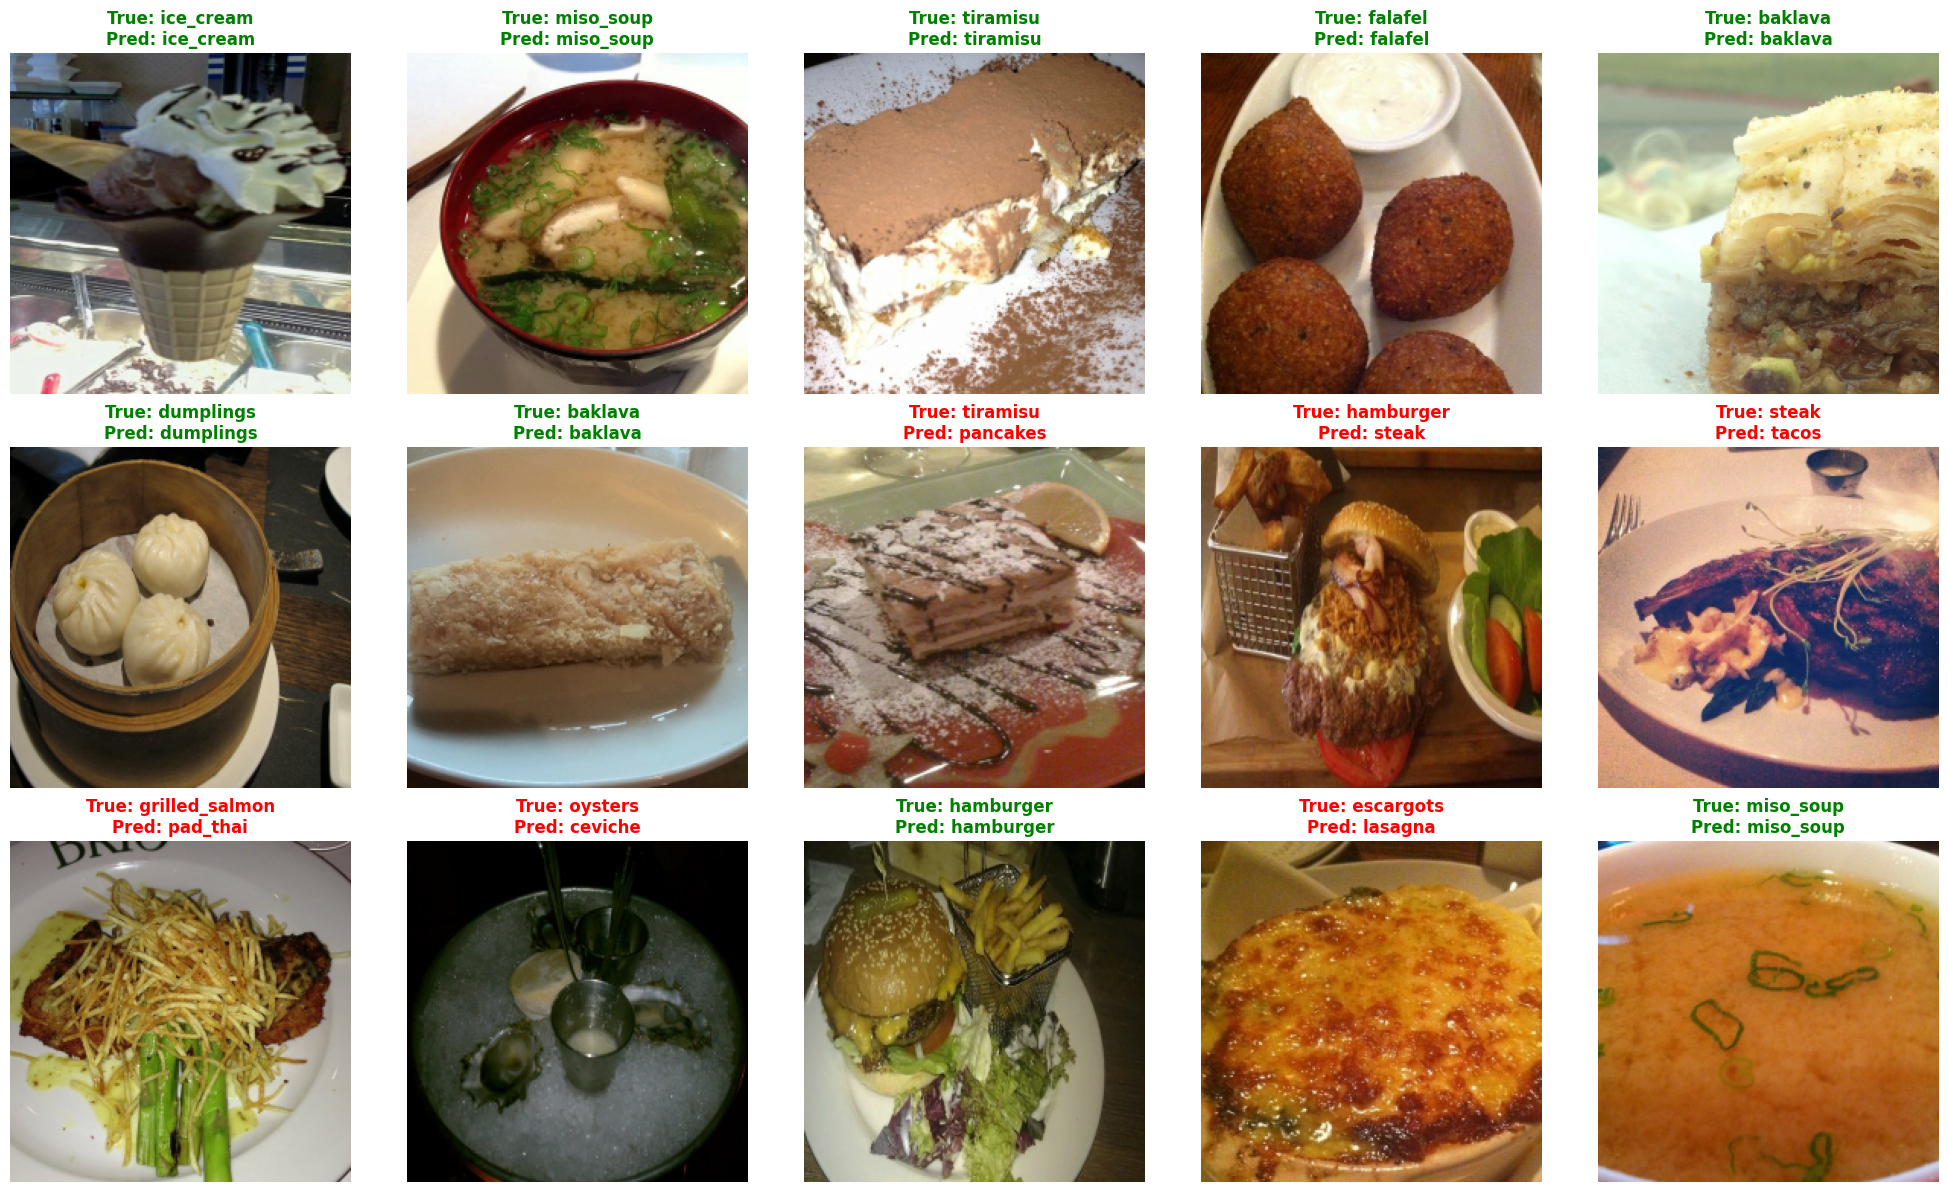

In [34]:
evaluation.visualize_predictions()

## Observation Description

## Conclusion